# 3. Grid analysis

Repeats the H2 standard-network analysis for runs made with `gce_tools`
(`02_temperature_grid.ipynb`). Each run is the run YAML plus overrides, so the
network, planet and output-file naming all come from the same config used to run
the solver. Element budgets and phase masses are worked out from the network
file, so they follow automatically if you add species or elements.

Edit the **Runs** cell, then run all.

In [180]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import LogLocator, NullFormatter

from gce_tools.analysis import (load_run, tex_species, rock_vapour_species, phase_label)

## Runs

In [181]:
CONFIG = "run_toi561b.yaml"
RUN_ROOT = Path("/Users/mcgintya/Documents/Python_scripts/GlobalChemicalEquilibrium_model/Standard_Version/runs/TOI_561b/Results/MgSiO3_melt/H2_atm")

# One entry per grid. `planet` / `grid` override the matching blocks of CONFIG.
# For files written with a different name, add e.g.
#   grid={"run_dir": ..., "output_name": "{planet}_H2_Ps_1000_Ts_{T}.dat"}
RUNS = [
    dict(planet={"surface_pressure_bar": 1000}, grid={"run_dir": RUN_ROOT / "1000_bar"}),
    dict(planet={"surface_pressure_bar": 100},  grid={"run_dir": RUN_ROOT / "100_bar"}),
    dict(planet={"surface_pressure_bar": 10},   grid={"run_dir": RUN_ROOT / "10_bar"}),
    #dict(planet={"surface_pressure_bar": 1},    grid={"run_dir": RUN_ROOT / "1_bar"}),
]

TOL = None              # chi^2 tolerance; None -> grid.tol from the YAML
REF = 0                 # index of the run used for the single-run plots
ZOOM_T = (2800, 3400)   # K, "expanded temperature interval" panels

runs = [load_run(CONFIG, tol=TOL, **r) for r in RUNS]
ref = runs[REF]
net = ref.network
ATM = ref.atm_phase

# One colour and line style per run, used throughout
RUN_COLORS = [f"C{i}" for i in range(len(runs))]
RUN_LS = ["-", "--", "-.", ":"] * 3

Loaded 21 temperatures (2000-4000 K) from /Users/mcgintya/Documents/Python_scripts/GlobalChemicalEquilibrium_model/Standard_Version/runs/TOI_561b/Results/MgSiO3_melt/H2_atm/1000_bar  [21/21 converged, AMF0 = 7.053e-04]
Loaded 21 temperatures (2000-4000 K) from /Users/mcgintya/Documents/Python_scripts/GlobalChemicalEquilibrium_model/Standard_Version/runs/TOI_561b/Results/MgSiO3_melt/H2_atm/100_bar  [21/21 converged, AMF0 = 7.053e-05]
Loaded 21 temperatures (2000-4000 K) from /Users/mcgintya/Documents/Python_scripts/GlobalChemicalEquilibrium_model/Standard_Version/runs/TOI_561b/Results/MgSiO3_melt/H2_atm/10_bar  [21/21 converged, AMF0 = 7.053e-06]


In [182]:
# Gas species: rock vapour (dashed) then volatiles (solid), in network order
ROCK = rock_vapour_species(net, ATM)
EXCLUDE_ATM = ["O2"]           # left out of the composition plots, as before
ATM_SPECIES = ([s for s in net.phases[ATM].species if s in ROCK] +
               [s for s in net.phases[ATM].species if s not in ROCK])
ATM_SPECIES = [s for s in ATM_SPECIES if s not in EXCLUDE_ATM]

def species_colors(species):
    cmap = plt.get_cmap("tab10" if len(species) <= 10 else "tab20")
    return {sp: cmap(i % cmap.N) for i, sp in enumerate(species)}

ATM_COLORS = species_colors(ATM_SPECIES)
ATM_LS = {sp: "--" if sp in ROCK else "-" for sp in ATM_SPECIES}

def log_ticks(ax):
    ax.yaxis.set_major_locator(LogLocator(base=10, numticks=10))
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=tuple(range(2, 10)), numticks=100))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.tick_params(direction="in", which="both")

print(net.summary())
print("Rock vapour:", ROCK)

Network 'MgSiO3_H2': elements Si, Mg, O, Fe, H, Na, C
  gas       (11): H2, H2O, CO, CO2, CH4, O2, Fe, Mg, SiO, Na, SiH4
  silicate  (11): MgO, SiO2, MgSiO3, FeO, FeSiO3, Na2O, Na2SiO3, H2, H2O, CO, CO2
  metal     ( 4): Fe, Si, O, H
Rock vapour: ['Fe', 'Mg', 'SiO', 'Na', 'SiH4']


## Convergence and mass conservation
Left: step-to-step change in the converged planet mass, $(M_{i+1}-M_i)/M_0$, with $\pm10^{-5}$ guides.
Right: $\chi^2$ of the selected row (last row below tolerance, or the minimum if nothing converged).

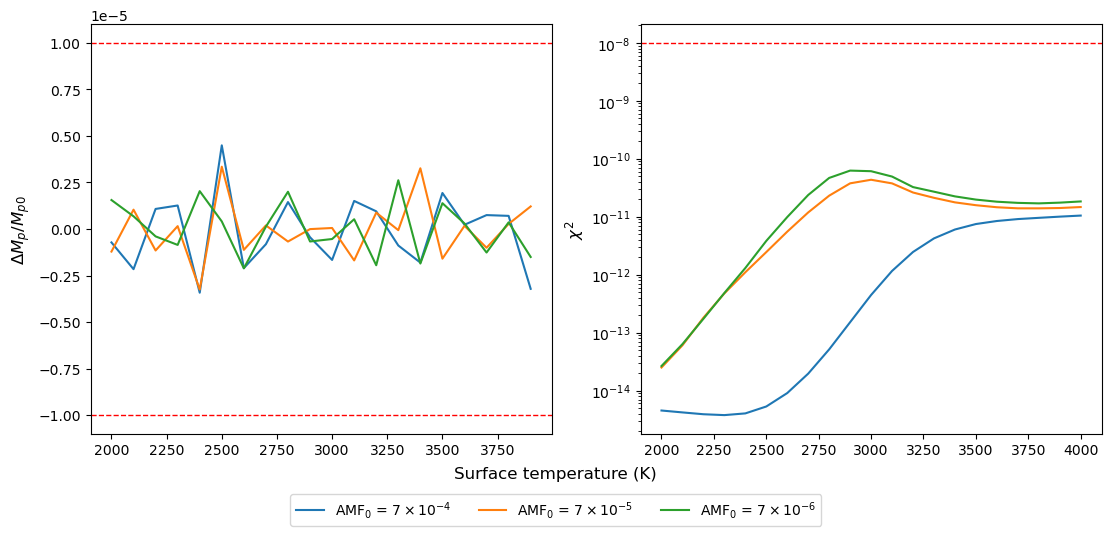

Ps0 =   1000 bar: max |M_total/M_planet - 1| = 2.41e-06
Ps0 =    100 bar: max |M_total/M_planet - 1| = 2.36e-06
Ps0 =     10 bar: max |M_total/M_planet - 1| = 2.34e-06


In [183]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), constrained_layout=True)

for run, c in zip(runs, RUN_COLORS):
    M = run.col("M_total_kg")
    axes[0].plot(run.T[:-1], np.diff(M) / M[0], color=c, label=run.label())
    axes[1].semilogy(run.T, run.col("chi^2"), color=c)
    bad = ~run.col("converged").astype(bool)
    axes[1].semilogy(run.T[bad], run.col("chi^2")[bad], "x", color=c)

for y in (1e-5, -1e-5):
    axes[0].axhline(y, color="red", ls="--", lw=1)
axes[1].axhline(ref.tol, color="red", ls="--", lw=1)

axes[0].set_ylabel(r"$\Delta M_p/M_{p0}$", fontsize=12)
axes[1].set_ylabel(r"$\chi^2$", fontsize=12)
fig.supxlabel("Surface temperature (K)")
fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center", ncols=len(runs),
           bbox_to_anchor=(0.5, -0.1), fontsize=10)
plt.show()

for run in runs:
    dev = run.col("M_total_over_M_planet") - 1
    print(f"Ps0 = {run.Ps0:6g} bar: max |M_total/M_planet - 1| = {np.abs(dev).max():.2e}")

## Atmospheric mass fraction

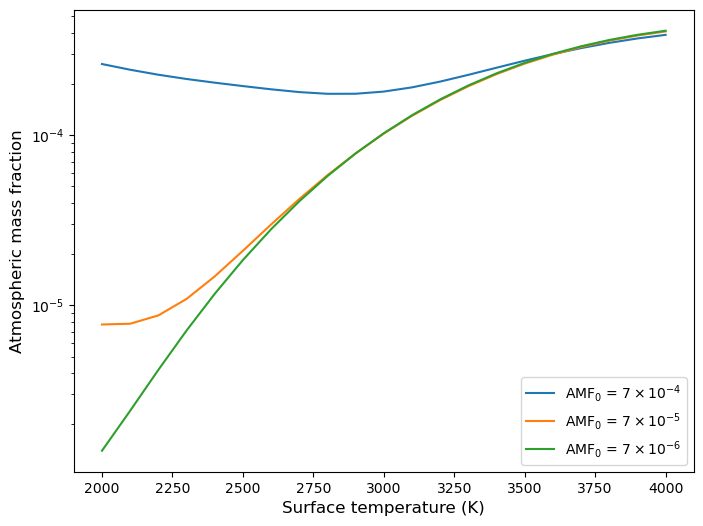

In [184]:
fig, ax = plt.subplots(figsize=(8, 6))
for run, c in zip(runs, RUN_COLORS):
    ax.semilogy(run.T, run.col("AMF"), color=c, label=run.label())
ax.set_xlabel("Surface temperature (K)", fontsize=12)
ax.set_ylabel("Atmospheric mass fraction", fontsize=12)
ax.legend()
plt.show()

## Surface pressure and elemental atmospheric mass
$P_s = M_{\rm atm}\,g/4\pi R^2$ from the converged atmosphere (as in `gce_tools`, using $g$ from the YAML planet mass).

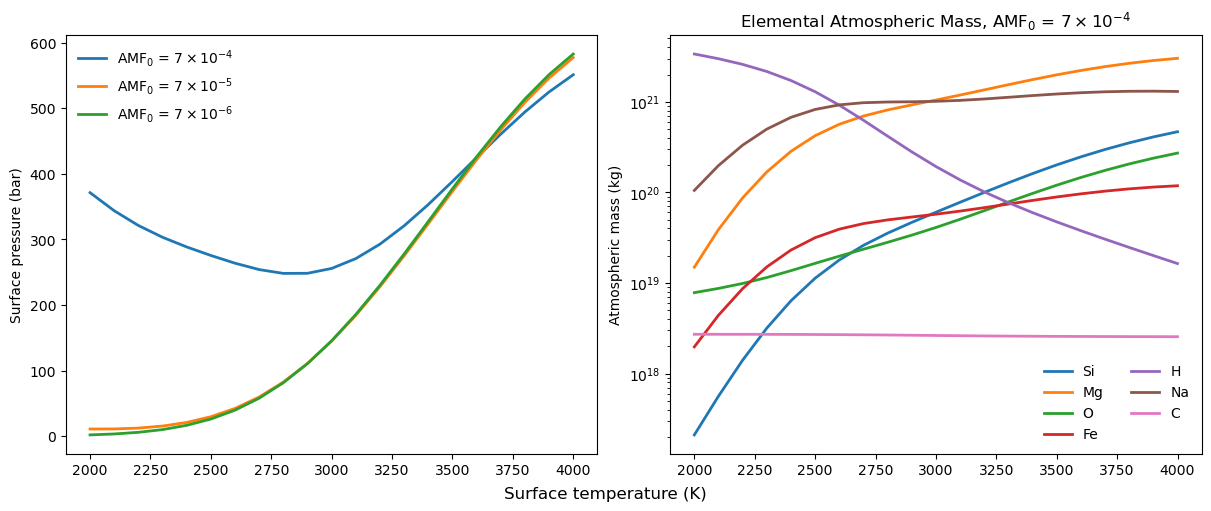

In [185]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 5), constrained_layout=True)

for run, c in zip(runs, RUN_COLORS):
    axes[0].plot(run.T, run.col("P_surface_bar"), lw=2, color=c, label=run.label())
axes[0].set_ylabel("Surface pressure (bar)")
axes[0].legend(frameon=False)

for el in net.elements:
    axes[1].semilogy(ref.T, ref.element_mass_kg(ATM, el), lw=2, label=el)
axes[1].set_title(f"Elemental Atmospheric Mass, {ref.label()}")
axes[1].set_ylabel("Atmospheric mass (kg)")
axes[1].legend(frameon=False, ncol=2)

fig.supxlabel("Surface temperature (K)")
plt.show()

## Atmosphere composition

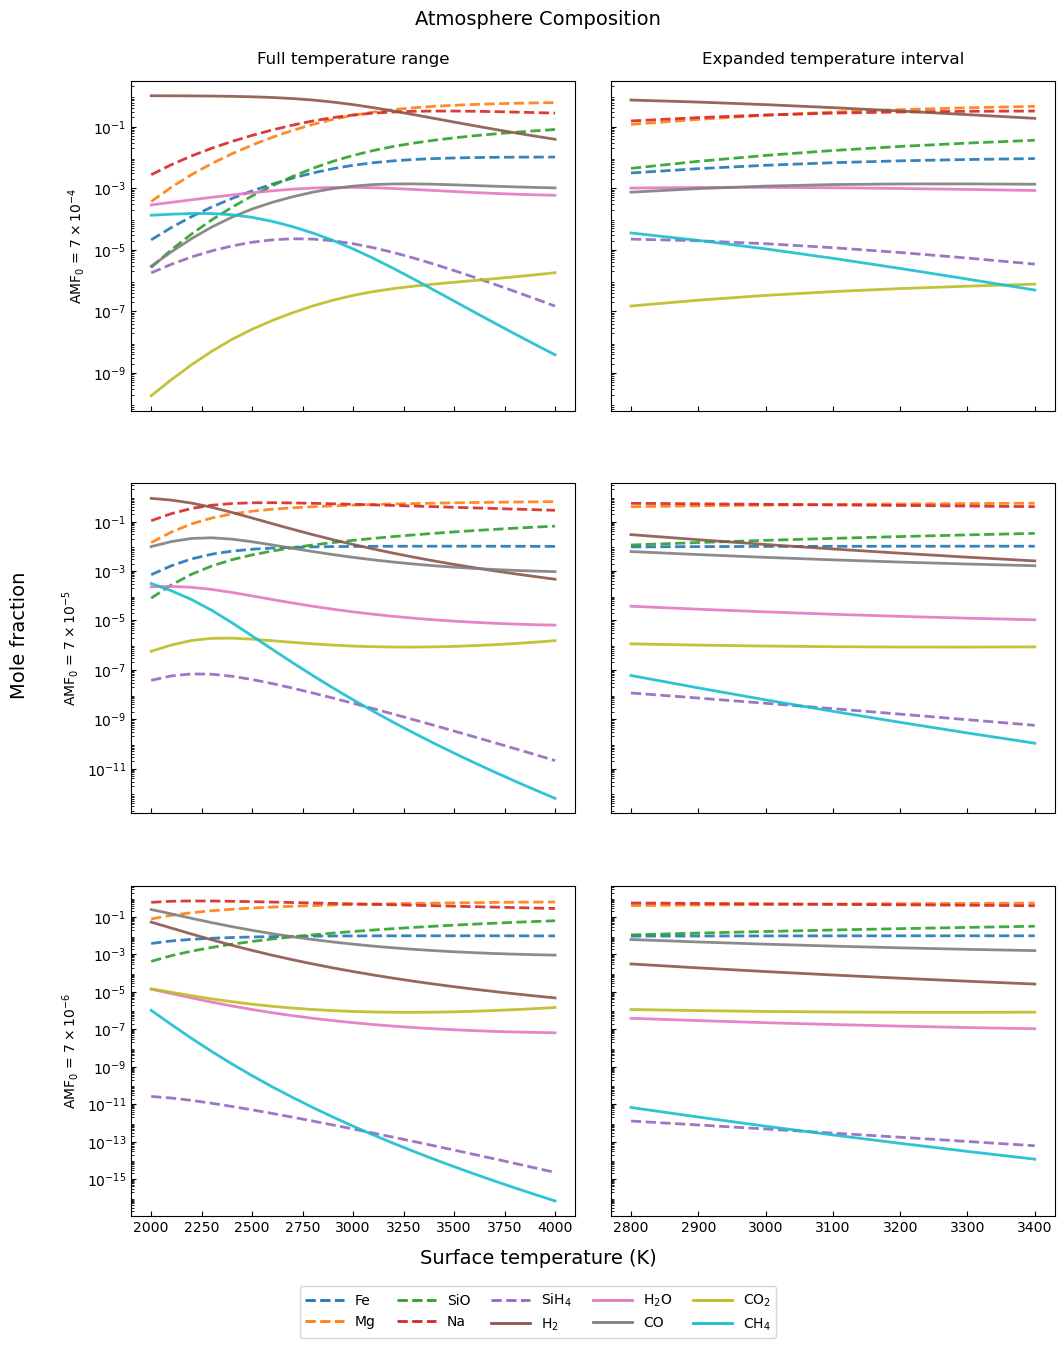

In [186]:
fig, axes = plt.subplots(nrows=len(runs), ncols=2, figsize=(11, 4.3 * len(runs)),
                         sharex="col", sharey="row", squeeze=False)

for row, run in enumerate(runs):
    full_ax, zoom_ax = axes[row]
    z = run.zoom(*ZOOM_T)
    for sp in ATM_SPECIES:
        kw = dict(color=ATM_COLORS[sp], ls=ATM_LS[sp], lw=2, alpha=0.9)
        full_ax.semilogy(run.T, run.x(ATM, sp), **kw)
        zoom_ax.semilogy(run.T[z], run.x(ATM, sp)[z], **kw)
    full_ax.set_ylabel(run.label(), fontsize=10)
    for a in (full_ax, zoom_ax):
        log_ticks(a)
    zoom_ax.tick_params(labelleft=False)

axes[0, 0].set_title("Full temperature range", fontsize=12, pad=12)
axes[0, 1].set_title("Expanded temperature interval", fontsize=12, pad=12)
fig.supxlabel("Surface temperature (K)", fontsize=14)
fig.supylabel("Mole fraction", fontsize=14)

handles = [Line2D([0], [0], color=ATM_COLORS[sp], ls=ATM_LS[sp], lw=2, label=tex_species(sp))
           for sp in ATM_SPECIES]
fig.legend(handles=handles, loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.05),
           columnspacing=1.5, handlelength=2.8)
fig.suptitle("Atmosphere Composition", fontsize=14, y=0.985)
fig.subplots_adjust(top=0.93, bottom=0.05, left=0.13, right=0.97, hspace=0.22, wspace=0.08)
plt.show()

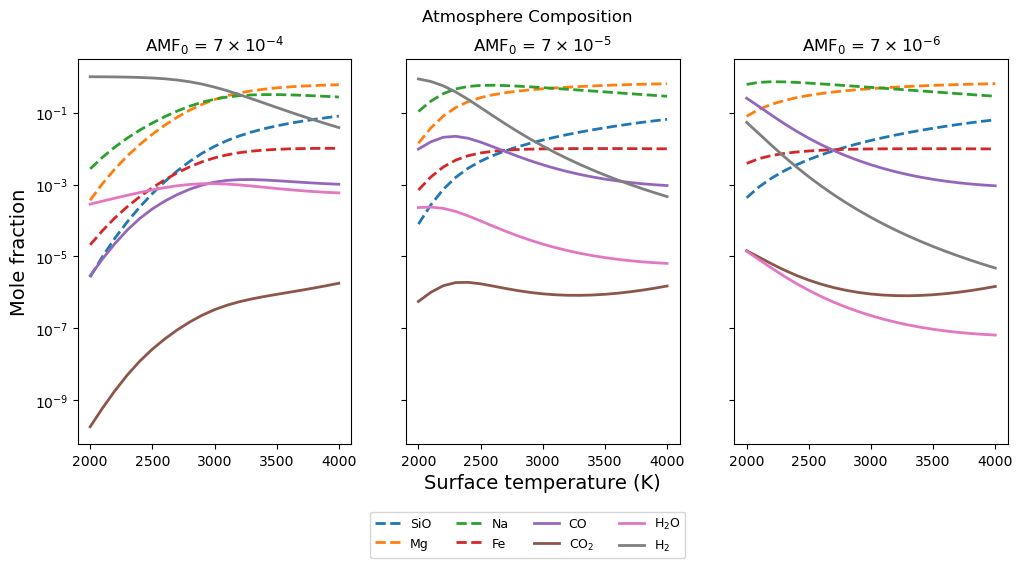

In [187]:
# Side-by-side runs, selected species only
SPECIES_TO_PLOT = ["SiO", "Mg", "Na", "Fe", "CO", "CO2", "H2O", "H2"]

colors = species_colors(SPECIES_TO_PLOT)
fig, axes = plt.subplots(1, len(runs), figsize=(4 * len(runs), 5), sharex=True, sharey=True,
                         squeeze=False)
for ax, run in zip(axes[0], runs):
    for sp in SPECIES_TO_PLOT:
        ax.semilogy(run.T, run.x(ATM, sp), color=colors[sp],
                    ls="--" if sp in ROCK else "-", lw=2)
    ax.set_title(run.label(), fontsize=12)

axes[0, len(runs) // 2].set_xlabel("Surface temperature (K)", fontsize=14)
axes[0, 0].set_ylabel("Mole fraction", fontsize=14)
handles = [Line2D([0], [0], color=colors[sp], ls="--" if sp in ROCK else "-", lw=2,
                  label=tex_species(sp)) for sp in SPECIES_TO_PLOT]
fig.legend(handles=handles, loc="lower center", ncol=min(4, len(SPECIES_TO_PLOT)),
           bbox_to_anchor=(0.5, -0.13), fontsize=9)
fig.suptitle("Atmosphere Composition", fontsize=12)
plt.show()

## Partial pressures vs. equilibrium vapour pressures
$p_i = x_i P_s$. Reference curves (bar):
- SiO: Gail et al. (2014), $p = e^{-T_v/T + S_v}/10^6$ with $T_v = 49520$, $S_v = 32.52$; and the Lee fit.
- Na: Bowles & Rosenblum (1965), $\log_{10} p = 4.54025 - 5242.11/T$.
- Fe(s), Fe(l): NIST-JANAF (Chase 1998) fits.

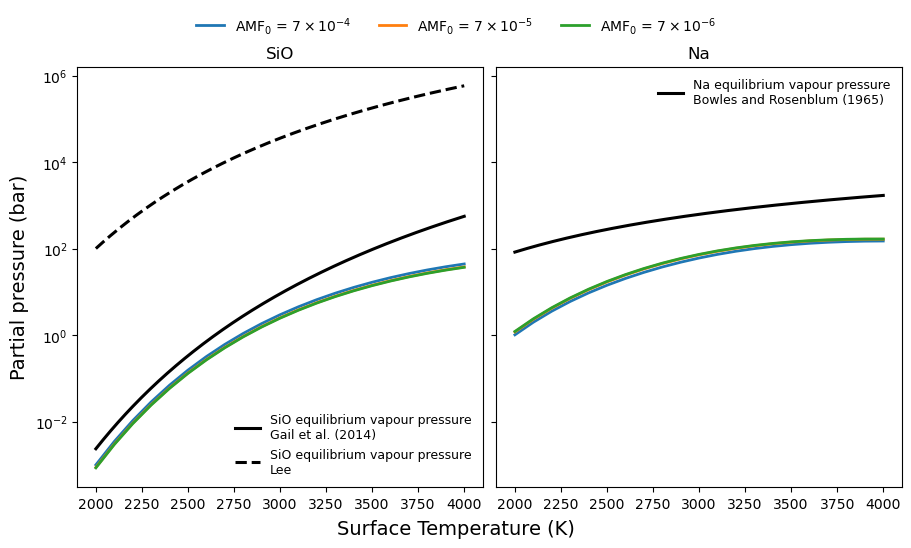

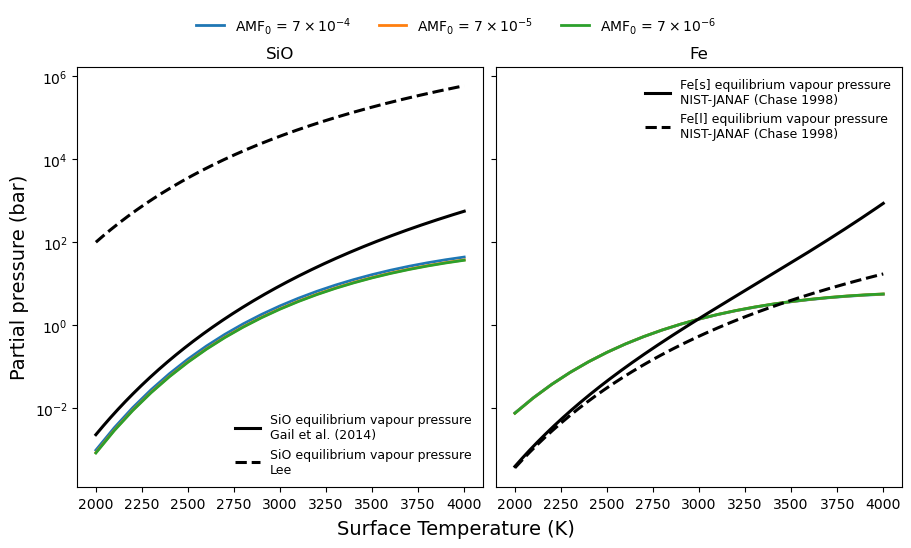

In [188]:
def poly_exp(A, B, C, D, E):
    # p [bar] = exp(A/T + B + C T + D T^2 + E T^3) / 1e6
    return lambda T: np.exp(A / T + B + C * T + D * T**2 + E * T**3) / 1e6

VAPOUR_REFS = {
    "SiO": [("SiO equilibrium vapour pressure\nGail et al. (2014)",
             lambda T: np.exp(-49520 / T + 32.52) / 1e6, "-"),
            ("SiO equilibrium vapour pressure\nLee",
             poly_exp(-3.88552548e+04, 3.97526713e+01, -1.24173202e-03,
                      1.64917838e-07, -9.66344862e-12), "--")],
    "Na":  [("Na equilibrium vapour pressure\nBowles and Rosenblum (1965)",
             lambda T: 10**(4.54025 - 5242.11 / T), "-")],
    "Fe":  [("Fe[s] equilibrium vapour pressure\nNIST-JANAF (Chase 1998)",
             poly_exp(-4.99622E+04, 3.21370E+01, 6.68363E-04, -1.13811E-06, 2.57277E-10), "-"),
            ("Fe[l] equilibrium vapour pressure\nNIST-JANAF (Chase 1998)",
             poly_exp(-4.87741E+04, 3.26355E+01, -1.38271E-03, 1.09701E-07, 0.0), "--")],
}

T_ref = np.linspace(min(r.T.min() for r in runs), max(r.T.max() for r in runs), 300)

def plot_partial_pressures(species_list):
    fig, axes = plt.subplots(ncols=len(species_list), figsize=(4.5 * len(species_list), 5),
                             sharex=True, sharey=True, constrained_layout=True, squeeze=False)
    for ax, sp in zip(axes[0], species_list):
        for run, c in zip(runs, RUN_COLORS):
            ax.semilogy(run.T, run.partial_pressure_bar(sp), color=c, lw=2)
        for label, f, ls in VAPOUR_REFS.get(sp, []):
            ax.semilogy(T_ref, f(T_ref), color="black", ls=ls, lw=2.2, label=label)
        ax.set_title(tex_species(sp))
        ax.legend(loc="best", frameon=False, fontsize=9)
    axes[0, 0].set_ylabel("Partial pressure (bar)", fontsize=14)
    handles = [Line2D([0], [0], color=c, lw=2, label=r.label()) for r, c in zip(runs, RUN_COLORS)]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.08),
               ncol=len(runs), frameon=False, fontsize=10)
    fig.supxlabel("Surface Temperature (K)", fontsize=14)
    plt.show()

plot_partial_pressures(["SiO", "Na"])
plot_partial_pressures(["SiO", "Fe"])

## Mantle and core composition

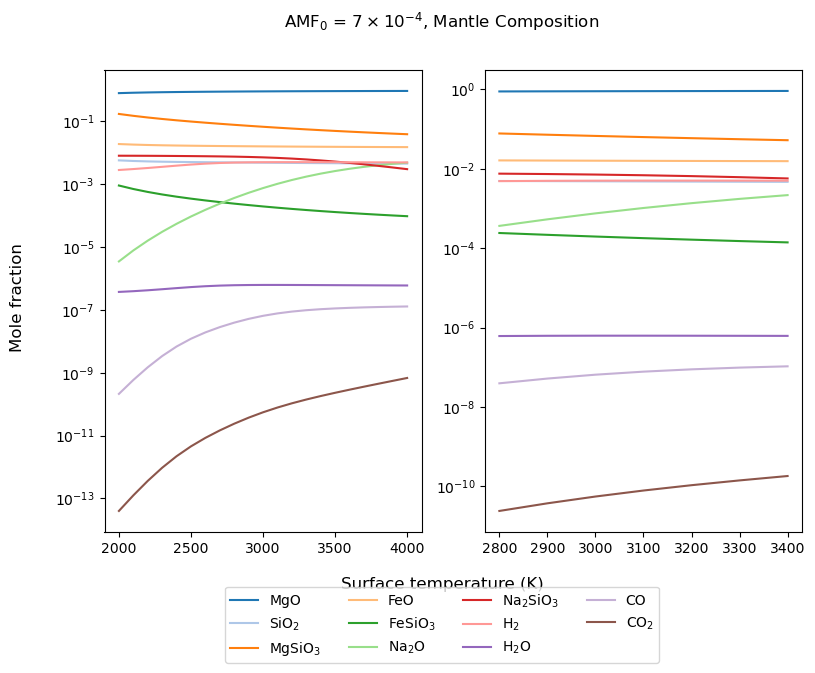

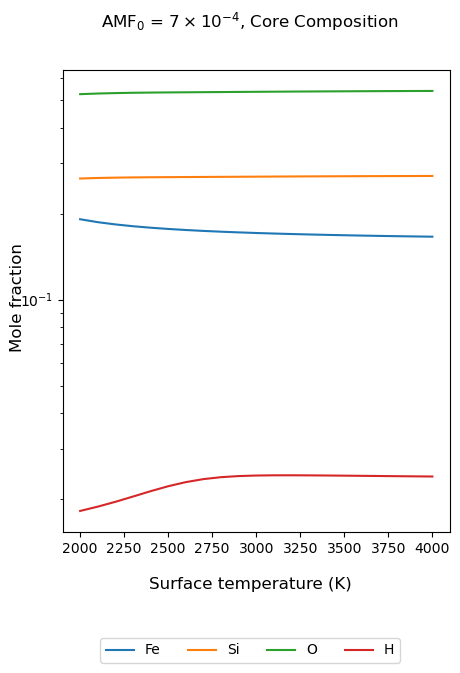

In [189]:
def plot_phase_composition(run, phase, zoom=True):
    species = list(run.network.phases[phase].species)
    colors = species_colors(species)
    ncols = 2 if zoom else 1
    fig, axes = plt.subplots(ncols=ncols, figsize=(4 * ncols + 1, 6), squeeze=False)
    z = run.zoom(*ZOOM_T)
    for sp in species:
        axes[0, 0].semilogy(run.T, run.x(phase, sp), color=colors[sp])
        if zoom:
            axes[0, 1].semilogy(run.T[z], run.x(phase, sp)[z], color=colors[sp])
    handles = [Line2D([0], [0], color=colors[sp], label=tex_species(sp)) for sp in species]
    fig.supxlabel("Surface temperature (K)")
    fig.supylabel("Mole fraction")
    fig.legend(handles=handles, loc="lower center", ncols=4, bbox_to_anchor=(0.5, -0.12))
    fig.suptitle(f"{run.label()}, {phase_label(phase) if phase != 'silicate' else 'Mantle'} Composition")
    plt.show()

plot_phase_composition(ref, "silicate", zoom=True)
plot_phase_composition(ref, "metal", zoom=False)

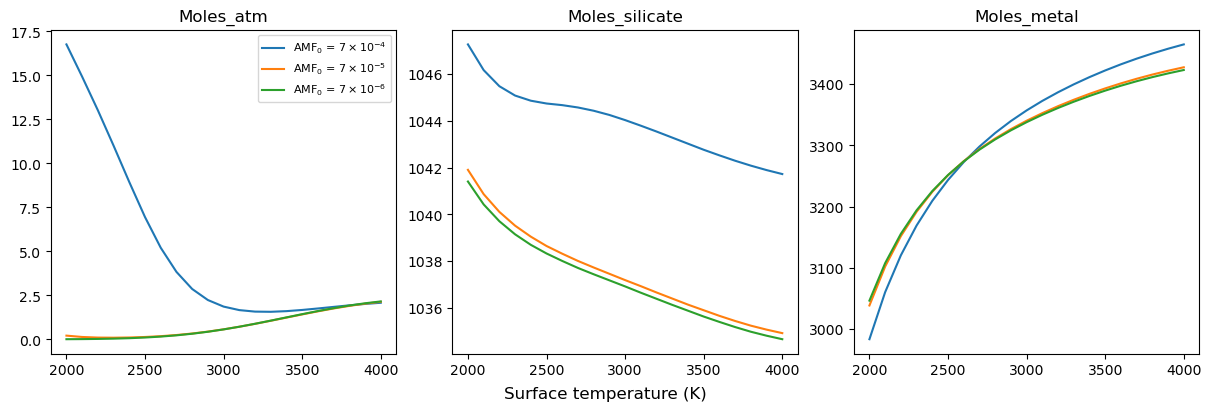

In [190]:
# Total moles in each phase (solver units of 1e23 mol)
fig, axes = plt.subplots(1, len(net.phases), figsize=(4 * len(net.phases), 4), constrained_layout=True)
for ax, (p, phase) in zip(axes, net.phases.items()):
    for run, c in zip(runs, RUN_COLORS):
        ax.plot(run.T, run.col(phase.moles_column), color=c, label=run.label())
    ax.set_title(phase.moles_column)
axes[0].legend(fontsize=8)
fig.supxlabel("Surface temperature (K)")
plt.show()

In [191]:
phase_mass = {
    phase: sum(run.element_mass_kg(phase, el) for el in run.network.elements)
    for phase in run.network.phases
}

silicate_mass   = phase_mass["silicate"]
atmosphere_mass = phase_mass["gas"]
metal_mass      = phase_mass["metal"]
planet_mass     = silicate_mass + atmosphere_mass + metal_mass   # array, one value per temperature
planet_mass/5.972e24

array([2.23924459, 2.23924807, 2.2392496 , 2.23924871, 2.23924679,
       2.23925135, 2.23925226, 2.23924753, 2.23924781, 2.23925229,
       2.23925079, 2.23924958, 2.23925076, 2.23924639, 2.23925226,
       2.2392481 , 2.23925121, 2.23925187, 2.23924904, 2.23924984,
       2.23924647])

## Element masses by reservoir

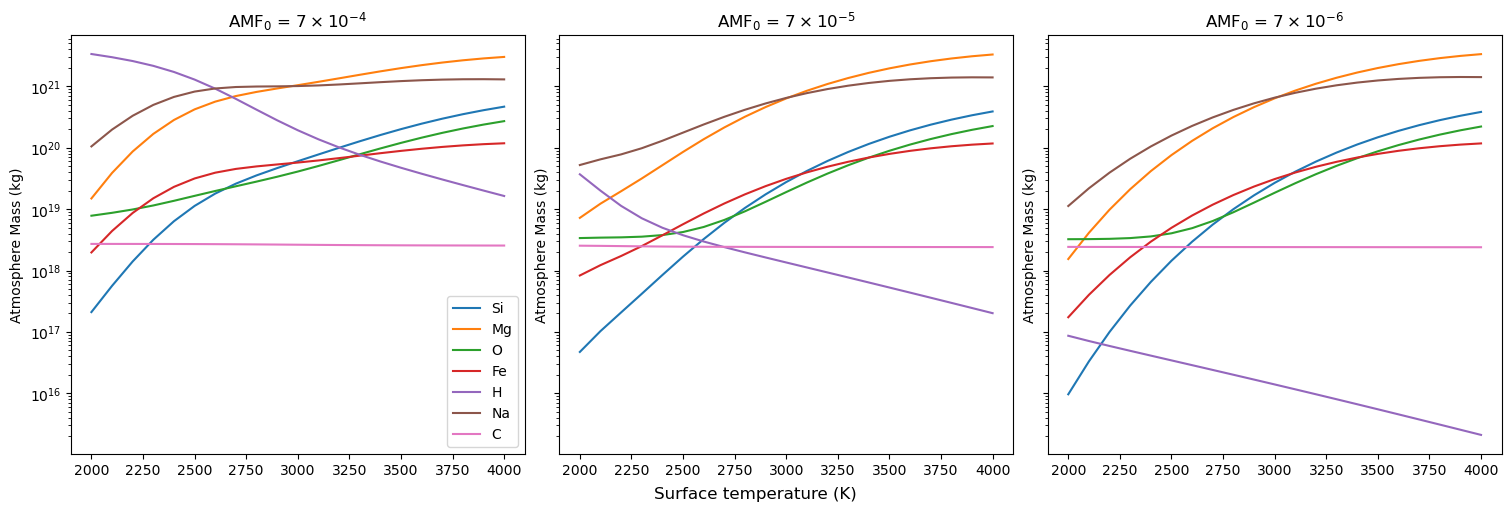

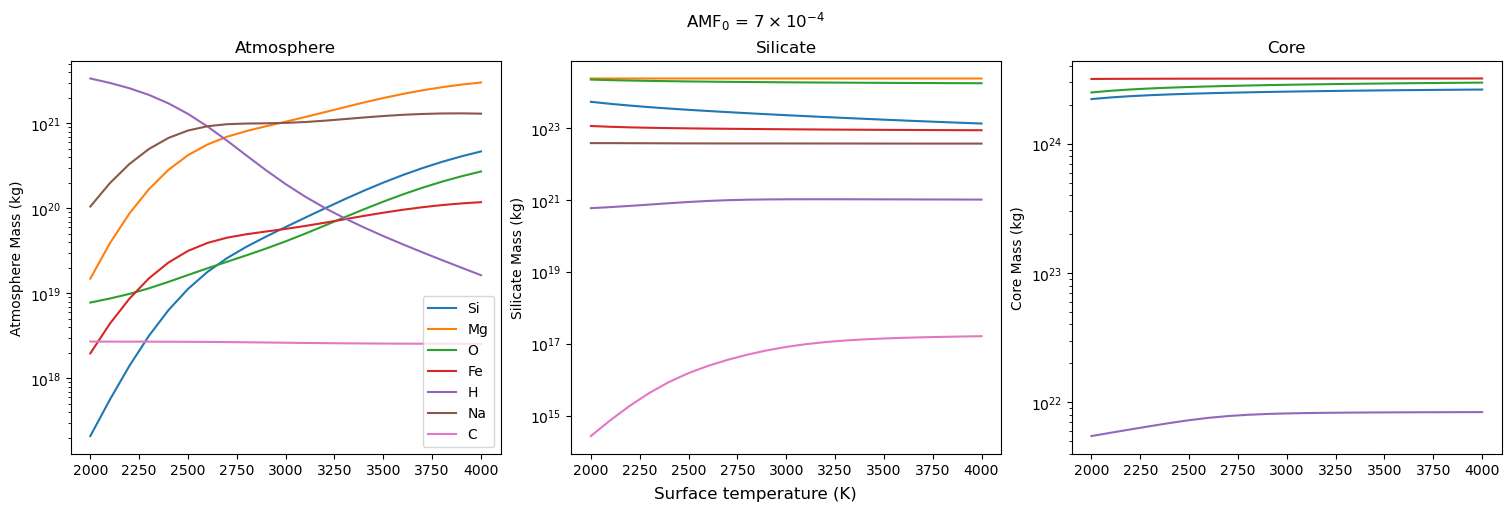

In [192]:
def plot_element_masses(ax, run, phase):
    for el in run.network.elements:
        ax.semilogy(run.T, run.element_mass_kg(phase, el), label=el)
    ax.set_ylabel(f"{phase_label(phase)} Mass (kg)")

# Atmosphere, every run
fig, axes = plt.subplots(1, len(runs), figsize=(5 * len(runs), 5), sharey=True,
                         constrained_layout=True, squeeze=False)
for ax, run in zip(axes[0], runs):
    plot_element_masses(ax, run, ATM)
    ax.set_title(run.label())
axes[0, 0].legend()
fig.supxlabel("Surface temperature (K)")
plt.show()

# Every reservoir, reference run
fig, axes = plt.subplots(1, len(net.phases), figsize=(5 * len(net.phases), 5),
                         constrained_layout=True)
for ax, phase in zip(axes, net.phases):
    plot_element_masses(ax, ref, phase)
    ax.set_title(phase_label(phase))
axes[0].legend()
fig.suptitle(ref.label())
fig.supxlabel("Surface temperature (K)")
plt.show()

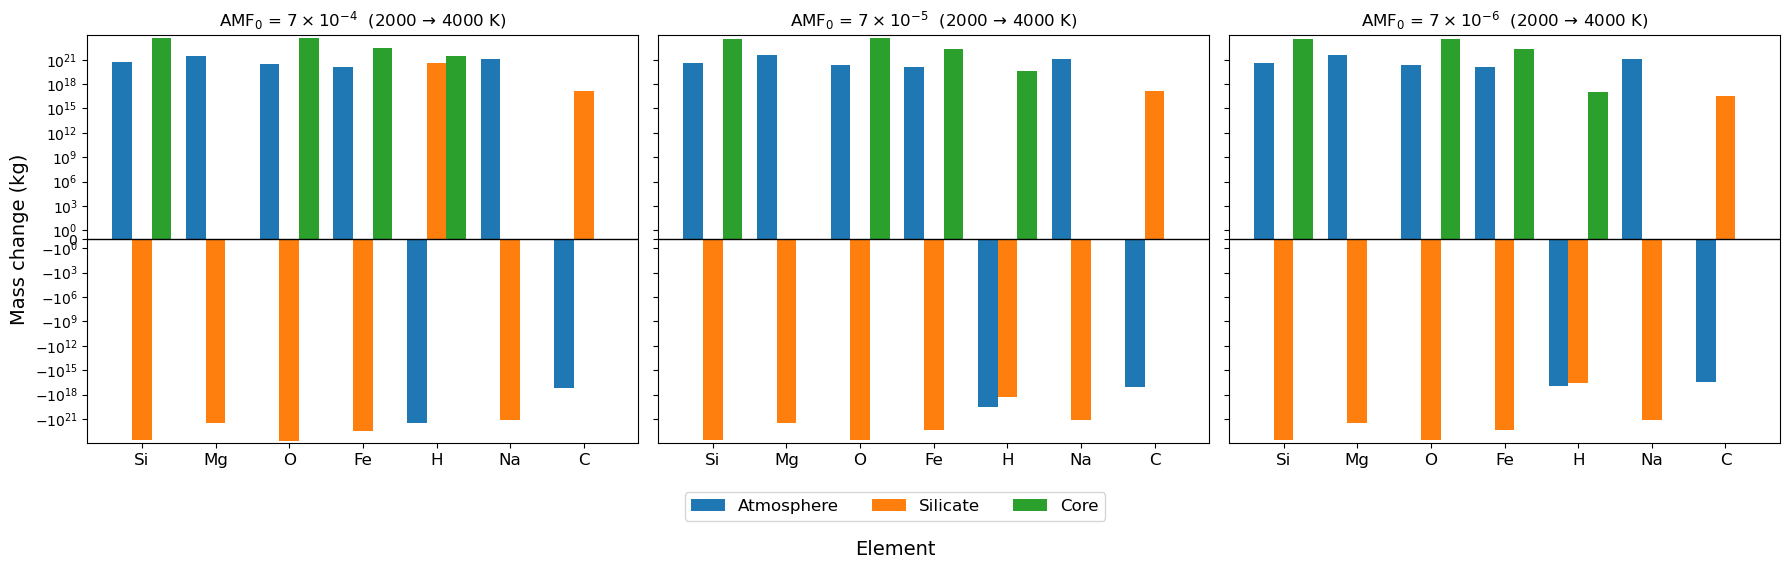

In [193]:
# Change in element mass in each reservoir between the lowest and highest temperature
width = 0.8 / len(net.phases)
x = np.arange(len(net.elements))
lim = max(np.abs(r.element_mass_change_kg(p)).max() for r in runs for p in net.phases)
lim = 10 ** np.ceil(np.log10(lim))

fig, axes = plt.subplots(1, len(runs), figsize=(6 * len(runs), 6), sharey=True, squeeze=False)
for ax, run in zip(axes[0], runs):
    for k, phase in enumerate(net.phases):
        offset = (k - (len(net.phases) - 1) / 2) * width
        ax.bar(x + offset, run.element_mass_change_kg(phase), width, label=phase_label(phase))
    ax.set_yscale("symlog", linthresh=1)
    ax.axhline(0, lw=1, color="black")
    ax.set_xticks(x)
    ax.set_xticklabels(net.elements, fontsize=12)
    ax.set_title(f"{run.label()}  ({run.T[0]:.0f} → {run.T[-1]:.0f} K)")
    ax.set_ylim(-lim, lim)

axes[0, 0].set_ylabel("Mass change (kg)", fontsize=14)
fig.supxlabel("Element", fontsize=14)
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="lower center", ncols=len(net.phases),
           bbox_to_anchor=(0.5, 0.06), fontsize=12)
fig.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

## Rock vapour vs. volatile fraction of the atmosphere

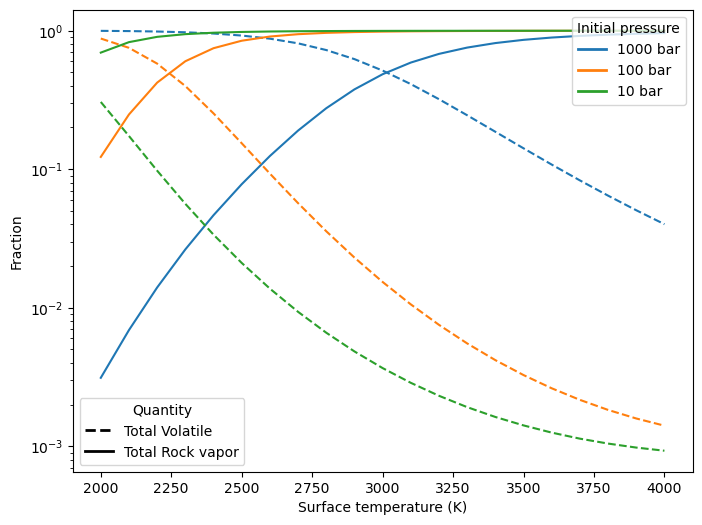

In [194]:
fig, ax = plt.subplots(figsize=(8, 6))
for run, c in zip(runs, RUN_COLORS):
    rock = sum(run.x(ATM, sp) for sp in ROCK)
    ax.semilogy(run.T, 1 - rock, color=c, ls="--")
    ax.semilogy(run.T, rock, color=c, ls="-")

ax.set_xlabel("Surface temperature (K)")
ax.set_ylabel("Fraction")
run_legend = ax.legend(handles=[Line2D([0], [0], color=c, lw=2, label=f"{r.Ps0:g} bar")
                                for r, c in zip(runs, RUN_COLORS)],
                       title="Initial pressure", loc="upper right")
ax.add_artist(run_legend)
ax.legend(handles=[Line2D([0], [0], color="k", lw=2, ls="--", label="Total Volatile"),
                   Line2D([0], [0], color="k", lw=2, ls="-", label="Total Rock vapor")],
          title="Quantity", loc="lower left")
plt.show()

In [195]:
# Optional: save the per-temperature tables
for run in runs:
     run.df.to_csv(run.cfg.run_dir / "analysis_summary.csv", index=False)